# Data Understanding

## Introduction

The first phase of every data mining project is understanding the available data. The goal of this notebook is to explore the structure of the Olist dataset, identify relationships between tables, examine data dimensions, analyze attribute types, and investigate missing values.

This analysis provides the foundation for subsequent preprocessing, feature engineering, and data mining tasks.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
customers = pd.read_csv("../data/raw/olist_customers_dataset.csv")
orders = pd.read_csv("../data/raw/olist_orders_dataset.csv")
items = pd.read_csv("../data/raw/olist_order_items_dataset.csv")
payments = pd.read_csv("../data/raw/olist_order_payments_dataset.csv")
reviews = pd.read_csv("../data/raw/olist_order_reviews_dataset.csv")
products = pd.read_csv("../data/raw/olist_products_dataset.csv")
sellers = pd.read_csv("../data/raw/olist_sellers_dataset.csv")
geolocation = pd.read_csv("../data/raw/olist_geolocation_dataset.csv")
translation = pd.read_csv("../data/raw/product_category_name_translation.csv")

## Dataset Dimensions

The first step is to examine the size of each table. This provides an overview of the dataset scale and helps identify the main entities of the system.

In [8]:
dataset_shapes = pd.DataFrame({
    "Table": [
        "customers",
        "orders",
        "order_items",
        "payments",
        "reviews",
        "products",
        "sellers",
        "geolocation"
    ],
    "Rows": [
        customers.shape[0],
        orders.shape[0],
        items.shape[0],
        payments.shape[0],
        reviews.shape[0],
        products.shape[0],
        sellers.shape[0],
        geolocation.shape[0]
    ],
    "Columns": [
        customers.shape[1],
        orders.shape[1],
        items.shape[1],
        payments.shape[1],
        reviews.shape[1],
        products.shape[1],
        sellers.shape[1],
        geolocation.shape[1]
    ]
})

dataset_shapes

,Table,Rows,Columns
0,customers,99441,5
1,orders,99441,8
2,order_items,112650,7
3,payments,103886,5
4,reviews,99224,7
5,products,32951,9
6,sellers,3095,4
7,geolocation,1000163,5


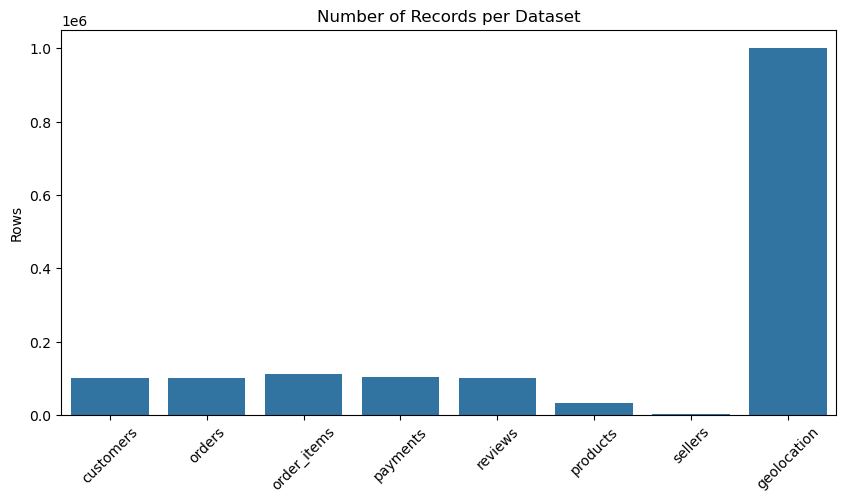

In [9]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=dataset_shapes,
    x="Table",
    y="Rows"
)

plt.title("Number of Records per Dataset")
plt.xlabel("")
plt.ylabel("Rows")

plt.xticks(rotation=45)

plt.show()

The dataset contains approximately 100 thousand orders and customers, over 112 thousand order items, nearly 33 thousand products, and more than 3 thousand sellers.

The largest table is the geolocation dataset, containing over one million records. This table will primarily be used for geographical analyses and feature engineering.

The size of the dataset indicates that it is sufficiently large for applying data mining techniques such as clustering, classification, association rule mining, and anomaly detection.

## Table Structure and Attribute Analysis

After examining the size of the datasets, the next step is to inspect the structure of each table. This includes column names, data types, and a small sample of records.

This step is important because different types of attributes require different preprocessing techniques. Numerical attributes can usually be scaled, categorical attributes need to be encoded, textual attributes require text processing, and date attributes need to be converted into meaningful time-based features.

In [10]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "geolocation": geolocation,
    "translation": translation
}

In [11]:
for name, df in datasets.items():
    print("=" * 80)
    print(name.upper())
    print("=" * 80)
    print(f"Shape: {df.shape}")
    print("\nColumns:")
    print(df.columns.tolist())
    print("\nData types:")
    print(df.dtypes.value_counts())
    display(df.head())

CUSTOMERS
Shape: (99441, 5)

Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Data types:
object    4
int64     1
Name: count, dtype: int64


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


ORDERS
Shape: (99441, 8)

Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Data types:
object    8
Name: count, dtype: int64


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


ORDER_ITEMS
Shape: (112650, 7)

Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Data types:
object     4
float64    2
int64      1
Name: count, dtype: int64


...

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


GEOLOCATION
Shape: (1000163, 5)

Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

Data types:
float64    2
object     2
int64      1
Name: count, dtype: int64


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


TRANSLATION
Shape: (71, 2)

Columns:
['product_category_name', 'product_category_name_english']

Data types:
object    2
Name: count, dtype: int64


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


The dataset contains a combination of identifiers, numerical variables, categorical attributes, timestamps, and textual fields.

The `orders` table contains several timestamp columns that will later be used to calculate delivery duration and delivery delay. The `reviews` table contains the target variable `review_score`, as well as textual review comments. The `order_items` and `payments` tables contain numerical transaction-related variables such as price, freight value, payment value, and number of installments.

These attributes will later be transformed into analytical features suitable for clustering, classification, association rule mining, and anomaly detection.

## Missing Values Analysis

Missing values are analyzed before preprocessing in order to identify incomplete attributes and decide how they should be handled in later stages of the project.

In [12]:
missing_summary = []

for name, df in datasets.items():
    missing_percent = df.isnull().mean() * 100
    
    for column, percent in missing_percent.items():
        if percent > 0:
            missing_summary.append({
                "Table": name,
                "Column": column,
                "Missing (%)": round(percent, 2)
            })

missing_summary = pd.DataFrame(missing_summary)
missing_summary.sort_values(by="Missing (%)", ascending=False)

,Table,Column,Missing (%)
3,reviews,review_comment_title,88.34
4,reviews,review_comment_message,58.70
2,orders,order_delivered_customer_date,2.98
6,products,product_name_lenght,1.85
5,products,product_category_name,1.85
7,products,product_description_lenght,1.85
8,products,product_photos_qty,1.85
1,orders,order_delivered_carrier_date,1.79
0,orders,order_approved_at,0.16
9,products,product_weight_g,0.01


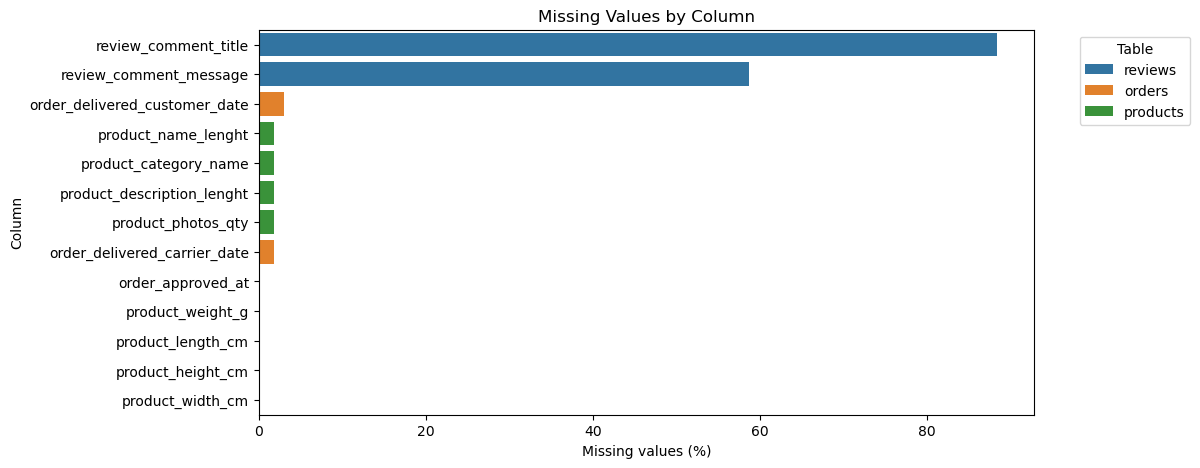

In [13]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=missing_summary.sort_values("Missing (%)", ascending=False),
    x="Missing (%)",
    y="Column",
    hue="Table",
    dodge=False
)

plt.title("Missing Values by Column")
plt.xlabel("Missing values (%)")
plt.ylabel("Column")

plt.legend(title="Table", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

The largest amount of missing data appears in the review text fields. The column `review_comment_title` has a very high percentage of missing values, while `review_comment_message` is missing in more than half of the records.

For this reason, `review_comment_title` will not be used in later modeling. However, `review_comment_message` may still be useful for text-based feature extraction because it is available for a substantial number of reviews.

The order delivery timestamp columns contain only a small percentage of missing values. Since these columns are required for calculating delivery-related features, records with missing delivery dates will be handled during preprocessing.

The products table has a small percentage of missing product category and product description information. Since the missing percentage is low, these records can either be removed or assigned to an unknown category depending on the analysis.

## Relationship Between Tables

The Olist dataset is relational, meaning that information about one business process is distributed across several connected tables. Understanding these relationships is necessary before creating analytical datasets for data mining.

The central entity in the dataset is the order. Each order is associated with one customer, may contain one or more items, can have one or more payments, and may receive a customer review. Order items connect orders with products and sellers.

In [14]:
relationships = pd.DataFrame({
    "Source Table": [
        "orders",
        "orders",
        "orders",
        "orders",
        "order_items",
        "order_items",
        "products",
        "customers",
        "sellers"
    ],
    "Key": [
        "customer_id",
        "order_id",
        "order_id",
        "order_id",
        "product_id",
        "seller_id",
        "product_category_name",
        "customer_zip_code_prefix",
        "seller_zip_code_prefix"
    ],
    "Target Table": [
        "customers",
        "order_items",
        "payments",
        "reviews",
        "products",
        "sellers",
        "translation",
        "geolocation",
        "geolocation"
    ]
})

relationships

,Source Table,Key,Target Table
0,orders,customer_id,customers
1,orders,order_id,order_items
2,orders,order_id,payments
3,orders,order_id,reviews
4,order_items,product_id,products
5,order_items,seller_id,sellers
6,products,product_category_name,translation
7,customers,customer_zip_code_prefix,geolocation
8,sellers,seller_zip_code_prefix,geolocation


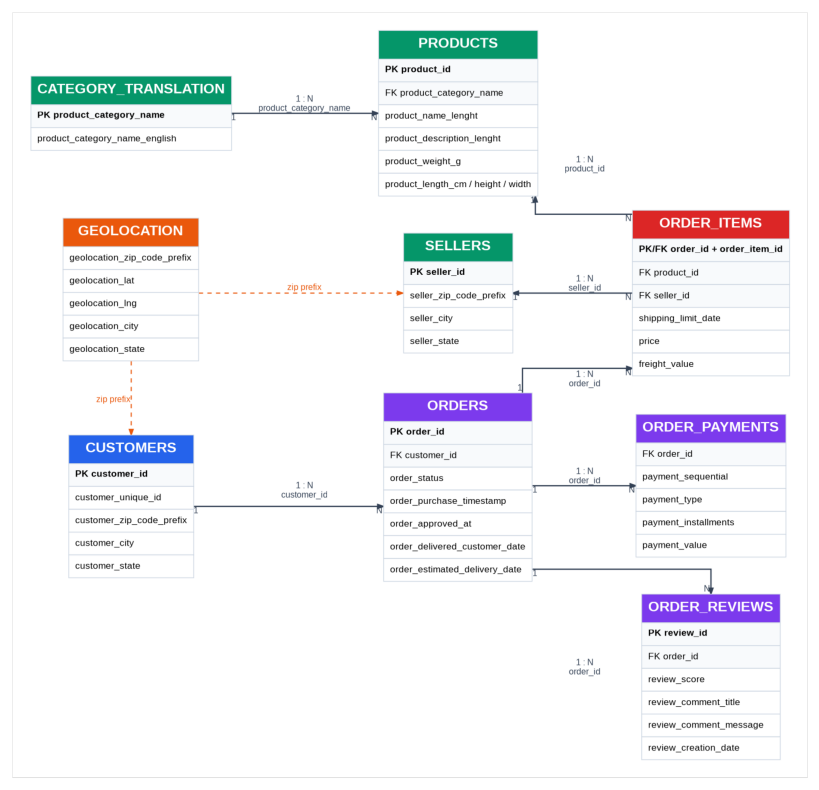

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread(
    "../figures/relational_schema.png"
)

plt.figure(figsize=(12,10))
plt.imshow(img)
plt.axis("off")
plt.show()


### Customer Identifier Analysis

The customers table contains two customer identifiers: `customer_id` and `customer_unique_id`.

A preliminary inspection shows that a single `customer_unique_id` may be associated with multiple `customer_id` values. According to the dataset documentation, `customer_id` identifies a specific order transaction, while `customer_unique_id` identifies the actual customer.

Therefore, customer-level analyses performed later in the project will use `customer_unique_id` as the primary customer identifier. This prevents the same customer from being counted multiple times when aggregating purchasing behavior across multiple orders.

In [33]:
customers["customer_id"].nunique()

99441

In [34]:
customers["customer_unique_id"].nunique()

96096

In [35]:
customers.groupby("customer_unique_id")["customer_id"].nunique().value_counts().head()

customer_id
1    93099
2     2745
3      203
4       30
5        8
Name: count, dtype: int64

## Review Score Analysis

Customer reviews provide direct feedback about the shopping experience and represent one of the most important sources of business information in the dataset.

Before using review scores for predictive modeling, it is necessary to examine their distribution and understand the overall level of customer satisfaction.

In [19]:
review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

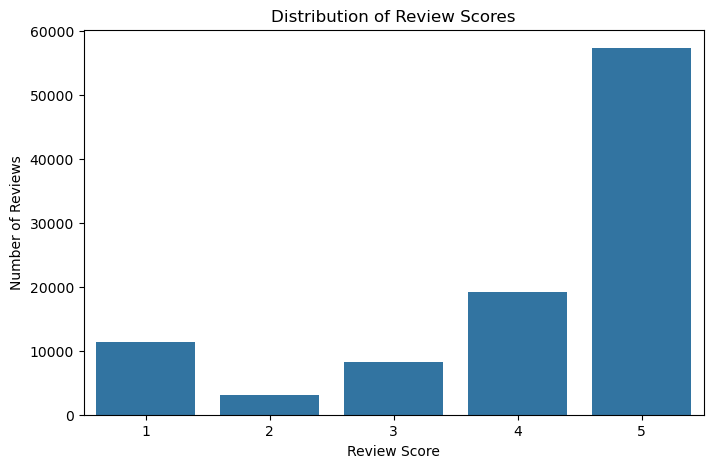

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=reviews,
    x="review_score"
)

plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.show()

In [21]:
review_percentages = (
    reviews["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

review_percentages

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

## Order Status Analysis

Order status provides insight into the operational performance of the platform. By examining the distribution of order statuses, we can evaluate how many orders were successfully completed and identify the presence of cancellations, unavailable products, or other fulfillment issues.

This analysis helps assess the overall reliability of the e-commerce platform before performing more advanced data mining tasks.

In [23]:
order_status_distribution = (
    orders["order_status"]
    .value_counts()
)

order_status_distribution

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

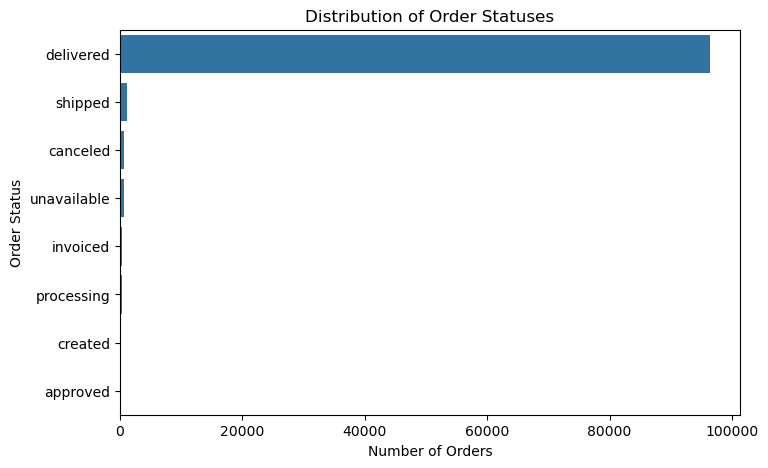

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=orders,
    y="order_status",
    order=orders["order_status"].value_counts().index
)

plt.title("Distribution of Order Statuses")
plt.xlabel("Number of Orders")
plt.ylabel("Order Status")

plt.show()

### Analysis

The distribution of order statuses is heavily dominated by completed deliveries. The vast majority of orders in the dataset have the status `delivered`, while all other statuses represent only a small fraction of the total number of transactions.

Statuses such as `canceled`, `unavailable`, and `processing` occur relatively infrequently, indicating that most orders successfully progress through the fulfillment process and reach customers.

This observation suggests that the platform operates with a high level of reliability and that most customer reviews are associated with successfully completed purchases. Consequently, future analyses focusing on customer satisfaction and purchasing behavior will primarily reflect the experience of customers whose orders were delivered successfully.

From a data mining perspective, the strong dominance of delivered orders should be considered when constructing predictive models involving order outcomes, since the target distribution is highly imbalanced.

## Orders Over Time

In [25]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [28]:
monthly_orders = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

monthly_orders.head()

order_purchase_timestamp
2016-09-30      4
2016-10-31    324
2016-11-30      0
2016-12-31      1
2017-01-31    800
Freq: ME, dtype: int64

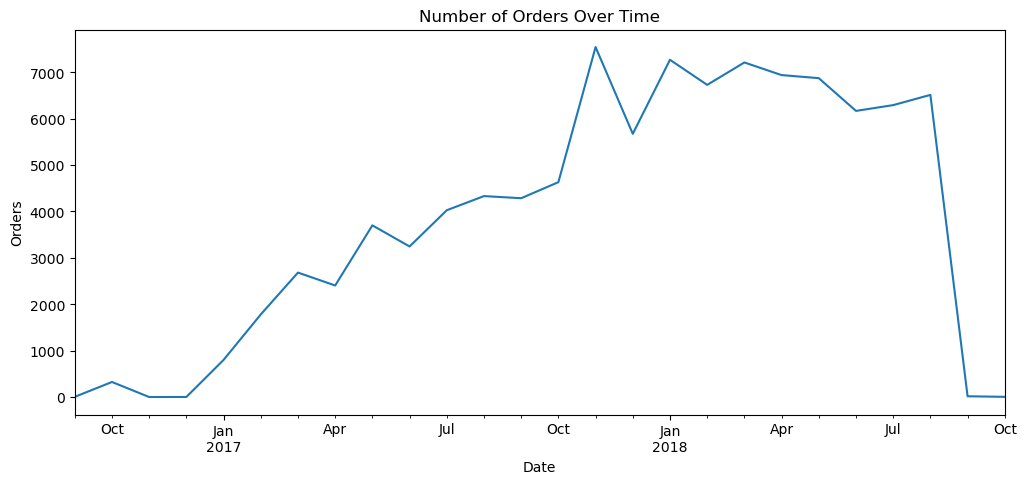

In [29]:
plt.figure(figsize=(12,5))

monthly_orders.plot()

plt.title("Number of Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Orders")

plt.show()

### Analysis

The number of orders increased substantially throughout the observed period, indicating strong growth of the platform.

During 2017, the volume of orders steadily increased, suggesting an expansion of the customer base and overall marketplace activity. The most significant growth occurred between the beginning of 2017 and the end of the same year, where monthly order volumes increased several times compared to the initial months.

Starting from late 2017 and continuing through most of 2018, the platform maintained a relatively stable level of activity, with monthly order volumes generally ranging between six and seven thousand orders.

The sharp decline observed at the end of the timeline should not be interpreted as a real decrease in business activity. Instead, it is most likely caused by the dataset ending before the final month was fully recorded, resulting in an incomplete observation period.

Overall, the time series suggests that the Olist platform experienced rapid growth followed by a period of stabilization, providing a rich transactional history suitable for customer behavior analysis and predictive modeling.

## Product Category Analysis

Product categories represent one of the most important sources of business information in the Olist dataset. They provide insight into the variety of products available on the platform and will later play a central role in customer segmentation, seller profiling, and association rule mining.

Analyzing the distribution of product categories helps identify the dominant segments of the marketplace and provides an initial understanding of the product portfolio offered through the platform.

In [39]:
products_en = products.merge(
    translation,
    on="product_category_name",
    how="left"
)

In [40]:
top_categories = (
    products_en["product_category_name_english"]
    .fillna("unknown")
    .value_counts()
    .head(15)
)

top_categories

product_category_name_english
bed_bath_table              3029
sports_leisure              2867
furniture_decor             2657
health_beauty               2444
housewares                  2335
auto                        1900
computers_accessories       1639
toys                        1411
watches_gifts               1329
telephony                   1134
baby                         919
perfumery                    868
stationery                   849
fashion_bags_accessories     849
cool_stuff                   789
Name: count, dtype: int64

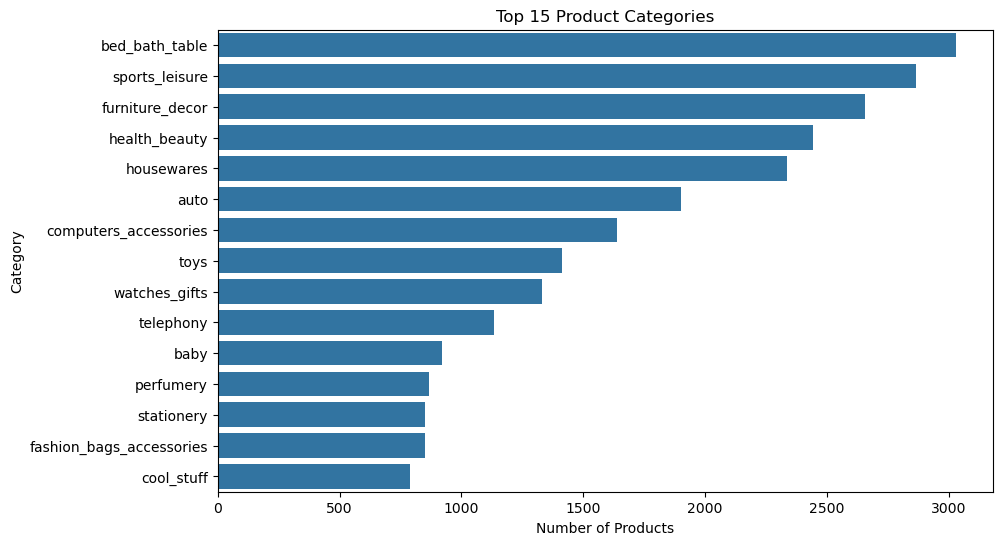

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title("Top 15 Product Categories")
plt.xlabel("Number of Products")
plt.ylabel("Category")

plt.show()

### Analysis

The most represented product categories include home-related products, sports and leisure equipment, furniture and decoration items, health and beauty products, and housewares.

The dominance of these categories suggests that the platform primarily serves everyday consumer needs rather than highly specialized market segments. The diversity of categories also indicates that purchasing behavior is likely heterogeneous, making the dataset suitable for customer segmentation and association rule mining.

Product categories will later be used to characterize purchasing preferences, identify customer segments, and discover frequently co-purchased product groups.

# Conclusion

In this notebook, the Olist dataset was explored in order to understand its structure, content, and suitability for data mining tasks.

The analysis showed that the dataset contains information about customers, orders, products, sellers, payments, reviews, and geographical locations organized across multiple interconnected tables. The relational structure is centered around the orders table, which links transactional, behavioral, and customer feedback information.

Data quality assessment revealed relatively low levels of missing data in most tables, with the exception of textual review fields. The review score distribution indicated a generally high level of customer satisfaction, while the order status analysis showed that the vast majority of transactions were successfully completed.

Temporal analysis demonstrated substantial growth of the platform throughout the observed period, followed by a phase of stable activity. Product category exploration revealed a diverse marketplace with strong representation of home-related, leisure, and health-oriented products.

Overall, the dataset provides sufficient volume, diversity, and quality of information to support a wide range of data mining tasks, including customer segmentation, seller segmentation, association rule mining, customer satisfaction prediction, and anomaly detection.

The next phase of the project focuses on data preparation, feature engineering, and the construction of analytical datasets that will be used for subsequent modeling.